In [81]:
import pandas as pd
import os
from matplotlib import pyplot as plt
import numpy as np

from tueplots import bundles
plt.rcParams.update(bundles.beamer_moml())
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'figure.dpi': 200})

In [82]:
df = pd.read_csv(os.path.join("..", "process_outputs", "baseline_results.csv"))
df

,environment,approach,seed,value
0,tiger,hardcoded,0,0.937465
1,tiger,hardcoded,1,0.926540
2,tiger,hardcoded,2,0.919124
3,tiger,hardcoded,3,0.915539
4,tiger,hardcoded,4,0.912385
...,...,...,...,...
275,four_rooms,random,8,0.000000
276,four_rooms,random,9,0.000000
277,lava,hardcoded,1,0.069514
278,lava,hardcoded,4,0.124062


In [83]:
# get the normalized values per environment and use that for plotting
df_normalized = df.groupby(['environment', 'approach'])['value'].mean().reset_index()

# Get the hardcoded mean per environment
hardcoded_means = (
    df_normalized[df_normalized['approach'] == 'hardcoded']
    .set_index('environment')['value']        # Series: env -> mean(hardcoded)
)

# Get a column with the env-specific hardcoded mean
df_normalized['hardcoded_mean'] = df_normalized['environment'].map(hardcoded_means)

# Normalize each mean by the hardcoded mean of that environment
df_normalized['value_norm'] = df_normalized['value'] / df_normalized['hardcoded_mean']
df_normalized

,environment,approach,value,hardcoded_mean,value_norm
0,corners,hardcoded,0.534309,0.534309,1.000000
1,corners,ours,0.394905,0.534309,0.739095
2,corners,random,0.066883,0.534309,0.125176
3,corners,tabular,0.095055,0.534309,0.177902
4,empty,hardcoded,0.922368,0.922368,1.000000
5,empty,ours,0.460642,0.922368,0.499412
6,empty,random,0.052304,0.922368,0.056706
7,empty,tabular,0.922368,0.922368,1.000000
8,four_rooms,hardcoded,0.527854,0.527854,1.000000
9,four_rooms,ours,0.260570,0.527854,0.493641


In [84]:
df_plot = df.groupby(['environment', 'approach'])['value'].agg(['mean', 'std']).reset_index()
df_plot = df_plot.merge(
    df_normalized[['environment', 'approach', 'value_norm']],
    on=['environment', 'approach'],
    how='left',
)
df_plot

,environment,approach,mean,std,value_norm
0,corners,hardcoded,0.534309,0.076479,1.000000
1,corners,ours,0.394905,0.113221,0.739095
2,corners,random,0.066883,0.049501,0.125176
3,corners,tabular,0.095055,0.095545,0.177902
4,empty,hardcoded,0.922368,0.000000,1.000000
5,empty,ours,0.460642,0.406114,0.499412
6,empty,random,0.052304,0.045104,0.056706
7,empty,tabular,0.922368,0.000000,1.000000
8,four_rooms,hardcoded,0.527854,0.041066,1.000000
9,four_rooms,ours,0.260570,0.121144,0.493641


In [85]:
envs = ["tiger", "rocksample", "empty", "corners", "lava", "four_rooms", "unlock"]
approaches = ["hardcoded", "ours", "tabular", "random"]
df_plot["environment"] = pd.Categorical(df_plot["environment"], categories=envs, ordered=True)
df_plot["approach"] = pd.Categorical(df_plot["approach"], categories=approaches, ordered=True)
df_plot = df_plot.sort_values(["environment", "approach"])
df_plot

,environment,approach,mean,std,value_norm
20,tiger,hardcoded,0.922284,0.009228,1.000000
21,tiger,ours,0.873731,0.076297,0.947356
23,tiger,tabular,0.489800,0.166187,0.531073
22,tiger,random,0.555444,0.181543,0.602248
16,rocksample,hardcoded,12.741056,1.203000,1.000000
17,rocksample,ours,2.699009,5.358349,0.211836
19,rocksample,tabular,5.769145,2.114775,0.452800
18,rocksample,random,-3.461351,2.499390,-0.271669
4,empty,hardcoded,0.922368,0.000000,1.000000
5,empty,ours,0.460642,0.406114,0.499412


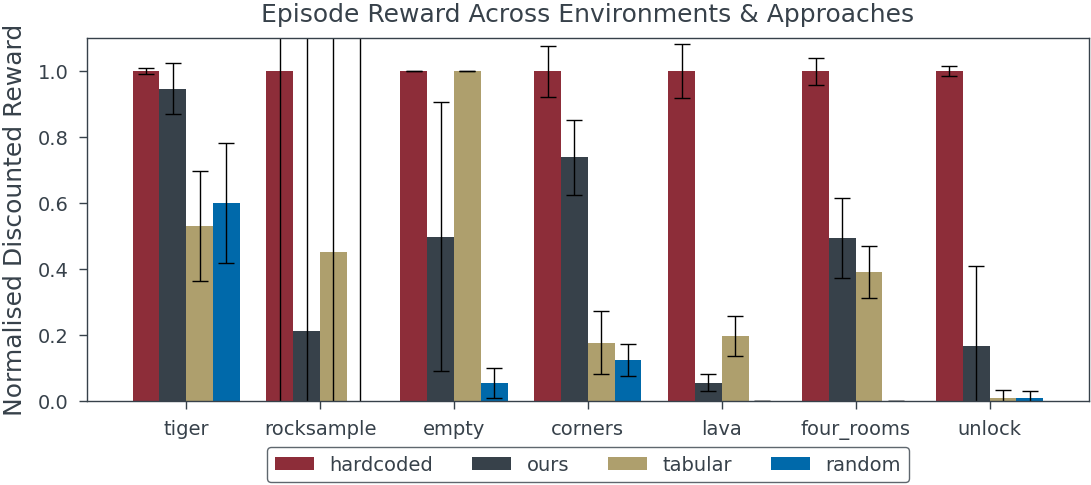

In [86]:
x = np.arange(len(envs))          # one base x for each environment
width = 0.2                       # bar width (tune for #approaches)

fig, ax = plt.subplots()

for i, approach in enumerate(approaches):
    data = df_plot[df_plot["approach"] == approach]
    means = data["value_norm"].values
    stds = data["std"].values

    # shift each approach within the environment group
    ax.bar(
        x + (i - len(approaches)/2) * width + width/2,
        means,
        width,
        yerr=stds,
        label=approach,
        capsize=3,
        error_kw=dict(linewidth=0.5, capthick=0.5),
    )

ax.set_xticks(x)
ax.set_xticklabels(envs)
ax.set_ylabel("Normalised Discounted Reward")
ax.set_title("Episode Reward Across Environments & Approaches")
ax.set_ylim(0, 1.1)
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.1))